<a href="https://colab.research.google.com/github/MojiburRahaman/colab-project/blob/main/regression/Diabetes_Detection_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, roc_curve, auc
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('diabetes-data.csv')
display(df.head())

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
display(df.head())
display(df.isnull().sum())
df.info()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (614, 8)
Shape of X_test: (154, 8)
Shape of y_train: (614,)
Shape of y_test: (154,)


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train = X_train_scaled
X_test = X_test_scaled

print("Scaled X_train shape:", X_train.shape)
print("Scaled X_test shape:", X_test.shape)

Scaled X_train shape: (614, 8)
Scaled X_test shape: (154, 8)


In [ ]:
# Initialize and train models
log_reg = LogisticRegression(random_state=42)
knn = KNeighborsClassifier()
dec_tree = DecisionTreeClassifier(random_state=42)

log_reg.fit(X_train, y_train)
knn.fit(X_train, y_train)
dec_tree.fit(X_train, y_train)

# predictions
y_pred_log_reg = log_reg.predict(X_test)
y_pred_knn = knn.predict(X_test)
y_pred_dec_tree = dec_tree.predict(X_test)

# predicted probabilities for ROC curve
y_prob_log_reg = log_reg.predict_proba(X_test)[:, 1]
y_prob_knn = knn.predict_proba(X_test)[:, 1]
y_prob_dec_tree = dec_tree.predict_proba(X_test)[:, 1]

# Evaluate models
print("--- Logistic Regression ---")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_log_reg))
print("Precision:", precision_score(y_test, y_pred_log_reg))
print("Recall:", recall_score(y_test, y_pred_log_reg))
print("F1-score:", f1_score(y_test, y_pred_log_reg))
fpr_log_reg, tpr_log_reg, _ = roc_curve(y_test, y_prob_log_reg)
auc_log_reg = auc(fpr_log_reg, tpr_log_reg)
print("AUC:", auc_log_reg)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall:", recall_score(y_test, y_pred_knn))
print("F1-score:", f1_score(y_test, y_pred_knn))
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)
auc_knn = auc(fpr_knn, tpr_knn)
print("AUC:", auc_knn)

print("\n--- Decision Tree ---")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dec_tree))
print("Precision:", precision_score(y_test, y_pred_dec_tree))
print("Recall:", recall_score(y_test, y_pred_dec_tree))
print("F1-score:", f1_score(y_test, y_pred_dec_tree))
fpr_dec_tree, tpr_dec_tree, _ = roc_curve(y_test, y_prob_dec_tree)
auc_dec_tree = auc(fpr_dec_tree, tpr_dec_tree)
print("AUC:", auc_dec_tree)

--- Logistic Regression ---
Confusion Matrix:
 [[79 20]
 [18 37]]
Precision: 0.6491228070175439
Recall: 0.6727272727272727
F1-score: 0.6607142857142857
AUC: 0.8146923783287419
Confusion Matrix:
 [[79 20]
 [27 28]]
Precision: 0.5833333333333334
Recall: 0.509090909090909
F1-score: 0.5436893203883495
AUC: 0.7640955004591368

--- Decision Tree ---
Confusion Matrix:
 [[75 24]
 [15 40]]
Precision: 0.625
Recall: 0.7272727272727273
F1-score: 0.6722689075630253
AUC: 0.7424242424242424


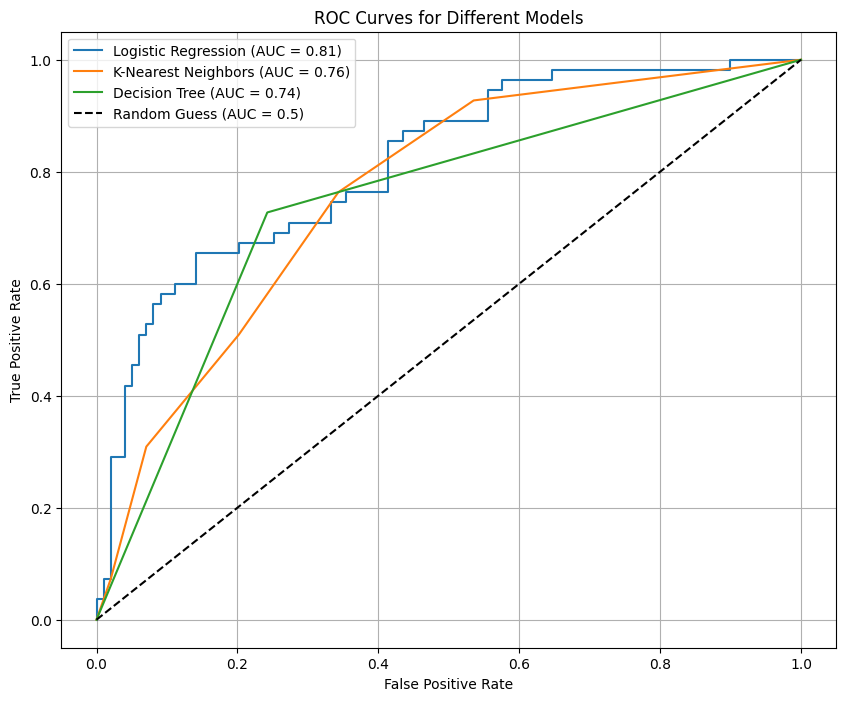

In [ ]:
plt.figure(figsize=(10, 8))
plt.plot(fpr_log_reg, tpr_log_reg, label=f'Logistic Regression (AUC = {auc_log_reg:.2f})')
plt.plot(fpr_knn, tpr_knn, label=f'K-Nearest Neighbors (AUC = {auc_knn:.2f})')
plt.plot(fpr_dec_tree, tpr_dec_tree, label=f'Decision Tree (AUC = {auc_dec_tree:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Different Models')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
metrics_data = {
    'Model': ['Logistic Regression', 'K-Nearest Neighbors', 'Decision Tree'],
    'Precision': [precision_score(y_test, y_pred_log_reg), precision_score(y_test, y_pred_knn), precision_score(y_test, y_pred_dec_tree)],
    'Recall': [recall_score(y_test, y_pred_log_reg), recall_score(y_test, y_pred_knn), recall_score(y_test, y_pred_dec_tree)],
    'F1-score': [f1_score(y_test, y_pred_log_reg), f1_score(y_test, y_pred_knn), f1_score(y_test, y_pred_dec_tree)],
    'AUC': [auc_log_reg, auc_knn, auc_dec_tree]
}

metrics_df = pd.DataFrame(metrics_data)
display(metrics_df)

,Model,Precision,Recall,F1-score,AUC
0,Logistic Regression,0.649123,0.672727,0.660714,0.814692
1,K-Nearest Neighbors,0.583333,0.509091,0.543689,0.764096
2,Decision Tree,0.625000,0.727273,0.672269,0.742424
